# Use Case 4 — AI Threat Modelling and Risk Prioritization

## Business Scenario
The delivery team is reviewing an ecommerce GenAI application before production.

They need a simple way to document:
- assets
- components
- threats
- attack paths
- risk scores
- controls
- security evidence

## Architecture / Threat-Modelling Flow

```text
Use Case
   |
   v
Assets & Components
   |
   v
Trust Boundaries
   |
   v
Threats & Attack Paths
   |
   v
Likelihood + Impact
   |
   v
Risk Priority
   |
   v
Control
   |
   v
Evidence
```

## Training Formula

```text
Risk Score = Likelihood × Impact
```

This is a simple teaching approach, not a universal enterprise scoring standard.

In [1]:
# Install required libraries once.
# pip install pandas matplotlib

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

## Step 1 — Load the Threat-Model CSV

In [3]:
df = pd.read_csv("ai_threat_model.csv")
df

,asset,component,threat,attack_path,likelihood,impact,owasp_mapping,candidate_control,evidence
0,User Prompt,Chat Interface,Direct prompt injection,User enters conflicting instructions through n...,5,4,Prompt Injection,Input scoping + injection filtering + regressi...,Prompt test report
1,System Prompt,Prompt Layer,Prompt leakage,User asks model to reveal hidden instructions,3,3,Sensitive Information Disclosure,Minimize sensitive prompt content + refusal be...,Prompt leakage test report
2,Customer Data,CRM Context,Sensitive-data disclosure,Model receives more customer data than required,3,5,Sensitive Information Disclosure,Authorization + data minimization + output ins...,Authorization and disclosure tests
3,Retrieved Content,Knowledge Base,Indirect prompt injection,Poisoned document contains malicious model ins...,4,4,Prompt Injection,Source controls + sanitization + instruction/d...,Poisoned-document test
4,LLM Output,Response Handler,Unsafe downstream handling,Generated output is trusted or executed withou...,3,5,Insecure Output Handling,Output validation + encoding + no blind execution,Output validation test
5,Tool Permission,Agent Tool Layer,Excessive agency,Model can invoke actions beyond business need,3,5,Excessive Agency,Least privilege + allow-list + approval gate,Tool-permission test
6,Logs,Observability,Sensitive information in logs,Prompts or outputs store PII without redaction,3,4,Sensitive Information Disclosure,Redaction + restricted access,Log review
7,API Key,Application Runtime,Secret exposure,Credential is stored in source code or notebook,2,5,Supply Chain / Secrets,Environment variables + secret manager,Secret scan
8,Knowledge Base,Document Ingestion,Data poisoning,Untrusted source changes support guidance,3,4,Data & Model Poisoning,Trusted-source policy + ingestion checks,Ingestion test
9,External API,Integration Layer,Unauthorized action,Model-generated parameters trigger unwanted op...,2,5,Excessive Agency,Schema validation + action approval,Integration test


## Step 2 — Review Assets and Components

Notice that the threat model includes more than the LLM:
- user prompt
- system prompt
- CRM/customer context
- knowledge base
- response handler
- tool layer
- logs
- API credentials

In [4]:
df[["asset","component","threat","attack_path"]]

,asset,component,threat,attack_path
0,User Prompt,Chat Interface,Direct prompt injection,User enters conflicting instructions through n...
1,System Prompt,Prompt Layer,Prompt leakage,User asks model to reveal hidden instructions
2,Customer Data,CRM Context,Sensitive-data disclosure,Model receives more customer data than required
3,Retrieved Content,Knowledge Base,Indirect prompt injection,Poisoned document contains malicious model ins...
4,LLM Output,Response Handler,Unsafe downstream handling,Generated output is trusted or executed withou...
5,Tool Permission,Agent Tool Layer,Excessive agency,Model can invoke actions beyond business need
6,Logs,Observability,Sensitive information in logs,Prompts or outputs store PII without redaction
7,API Key,Application Runtime,Secret exposure,Credential is stored in source code or notebook
8,Knowledge Base,Document Ingestion,Data poisoning,Untrusted source changes support guidance
9,External API,Integration Layer,Unauthorized action,Model-generated parameters trigger unwanted op...


## Step 3 — Calculate the Risk Score

In [5]:
df["risk_score"] = df["likelihood"] * df["impact"]

df[[
    "asset","threat","likelihood","impact","risk_score"
]]

,asset,threat,likelihood,impact,risk_score
0,User Prompt,Direct prompt injection,5,4,20
1,System Prompt,Prompt leakage,3,3,9
2,Customer Data,Sensitive-data disclosure,3,5,15
3,Retrieved Content,Indirect prompt injection,4,4,16
4,LLM Output,Unsafe downstream handling,3,5,15
5,Tool Permission,Excessive agency,3,5,15
6,Logs,Sensitive information in logs,3,4,12
7,API Key,Secret exposure,2,5,10
8,Knowledge Base,Data poisoning,3,4,12
9,External API,Unauthorized action,2,5,10


## Step 4 — Convert Scores to Simple Risk Levels

In [6]:
def to_risk_level(score):
    if score >= 20:
        return "Critical"
    elif score >= 12:
        return "High"
    elif score >= 6:
        return "Medium"
    return "Low"

df["risk_level"] = df["risk_score"].apply(to_risk_level)
df[["asset","threat","risk_score","risk_level"]]

,asset,threat,risk_score,risk_level
0,User Prompt,Direct prompt injection,20,Critical
1,System Prompt,Prompt leakage,9,Medium
2,Customer Data,Sensitive-data disclosure,15,High
3,Retrieved Content,Indirect prompt injection,16,High
4,LLM Output,Unsafe downstream handling,15,High
5,Tool Permission,Excessive agency,15,High
6,Logs,Sensitive information in logs,12,High
7,API Key,Secret exposure,10,Medium
8,Knowledge Base,Data poisoning,12,High
9,External API,Unauthorized action,10,Medium


## Step 5 — Sort by Priority

In [7]:
priority = df.sort_values(
    ["risk_score","impact"],
    ascending=False
)

priority[[
    "asset","component","threat",
    "risk_score","risk_level"
]]

,asset,component,threat,risk_score,risk_level
0,User Prompt,Chat Interface,Direct prompt injection,20,Critical
3,Retrieved Content,Knowledge Base,Indirect prompt injection,16,High
2,Customer Data,CRM Context,Sensitive-data disclosure,15,High
4,LLM Output,Response Handler,Unsafe downstream handling,15,High
5,Tool Permission,Agent Tool Layer,Excessive agency,15,High
6,Logs,Observability,Sensitive information in logs,12,High
8,Knowledge Base,Document Ingestion,Data poisoning,12,High
7,API Key,Application Runtime,Secret exposure,10,Medium
9,External API,Integration Layer,Unauthorized action,10,Medium
1,System Prompt,Prompt Layer,Prompt leakage,9,Medium


## Step 6 — Review Framework Mapping

The mapping helps delivery teams use a consistent security vocabulary.

In [8]:
priority[[
    "threat","owasp_mapping","candidate_control"
]]

,threat,owasp_mapping,candidate_control
0,Direct prompt injection,Prompt Injection,Input scoping + injection filtering + regressi...
3,Indirect prompt injection,Prompt Injection,Source controls + sanitization + instruction/d...
2,Sensitive-data disclosure,Sensitive Information Disclosure,Authorization + data minimization + output ins...
4,Unsafe downstream handling,Insecure Output Handling,Output validation + encoding + no blind execution
5,Excessive agency,Excessive Agency,Least privilege + allow-list + approval gate
6,Sensitive information in logs,Sensitive Information Disclosure,Redaction + restricted access
8,Data poisoning,Data & Model Poisoning,Trusted-source policy + ingestion checks
7,Secret exposure,Supply Chain / Secrets,Environment variables + secret manager
9,Unauthorized action,Excessive Agency,Schema validation + action approval
1,Prompt leakage,Sensitive Information Disclosure,Minimize sensitive prompt content + refusal be...


## Step 7 — Review Control and Evidence Together

In [9]:
priority[[
    "threat",
    "risk_level",
    "candidate_control",
    "evidence"
]]

,threat,risk_level,candidate_control,evidence
0,Direct prompt injection,Critical,Input scoping + injection filtering + regressi...,Prompt test report
3,Indirect prompt injection,High,Source controls + sanitization + instruction/d...,Poisoned-document test
2,Sensitive-data disclosure,High,Authorization + data minimization + output ins...,Authorization and disclosure tests
4,Unsafe downstream handling,High,Output validation + encoding + no blind execution,Output validation test
5,Excessive agency,High,Least privilege + allow-list + approval gate,Tool-permission test
6,Sensitive information in logs,High,Redaction + restricted access,Log review
8,Data poisoning,High,Trusted-source policy + ingestion checks,Ingestion test
7,Secret exposure,Medium,Environment variables + secret manager,Secret scan
9,Unauthorized action,Medium,Schema validation + action approval,Integration test
1,Prompt leakage,Medium,Minimize sensitive prompt content + refusal be...,Prompt leakage test report


## Step 8 — Create a Simple Risk Chart

This chart is useful when explaining prioritization to non-security stakeholders.

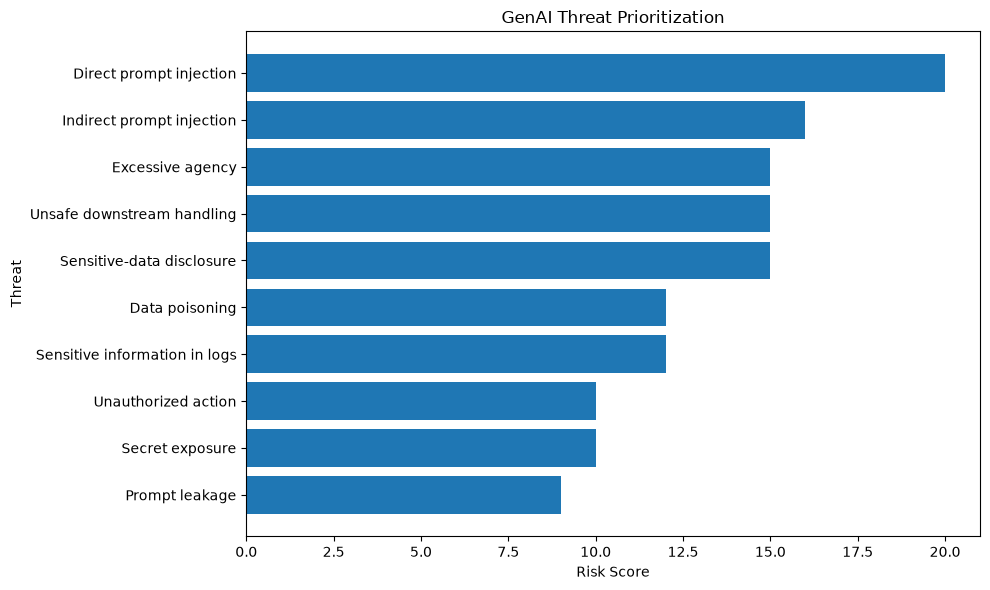

In [10]:
plot_df = priority.sort_values("risk_score")

plt.figure(figsize=(10, 6))
plt.barh(plot_df["threat"], plot_df["risk_score"])
plt.xlabel("Risk Score")
plt.ylabel("Threat")
plt.title("GenAI Threat Prioritization")
plt.tight_layout()
plt.show()

## Step 9 — Filter Only High and Critical Risks

In [11]:
high_priority = priority[
    priority["risk_level"].isin(["High","Critical"])
]

high_priority[[
    "asset","threat","risk_level",
    "candidate_control","evidence"
]]

,asset,threat,risk_level,candidate_control,evidence
0,User Prompt,Direct prompt injection,Critical,Input scoping + injection filtering + regressi...,Prompt test report
3,Retrieved Content,Indirect prompt injection,High,Source controls + sanitization + instruction/d...,Poisoned-document test
2,Customer Data,Sensitive-data disclosure,High,Authorization + data minimization + output ins...,Authorization and disclosure tests
4,LLM Output,Unsafe downstream handling,High,Output validation + encoding + no blind execution,Output validation test
5,Tool Permission,Excessive agency,High,Least privilege + allow-list + approval gate,Tool-permission test
6,Logs,Sensitive information in logs,High,Redaction + restricted access,Log review
8,Knowledge Base,Data poisoning,High,Trusted-source policy + ingestion checks,Ingestion test


## Step 10 — Export the Prioritized Threat Model

In [12]:
output_file = "prioritized_ai_threat_model.csv"
priority.to_csv(output_file, index=False)
print("Saved:", output_file)

Saved: prioritized_ai_threat_model.csv


## Expected Outcome

Participants should be able to explain:

```text
Asset
  ->
Threat
  ->
Attack Path
  ->
Likelihood / Impact
  ->
Risk Priority
  ->
Control
  ->
Evidence
```

This makes threat modelling practical and easy to present.